# 들락날락 후보지 주변 환경

- 주거지, 주차장, 역, 정류장의 개수를 확인할 것

In [64]:
import geopandas as gpd
import pandas as pd
import numpy as np

In [65]:
center_gdf = gpd.read_file('클러스터링/clusters_gdf_all_gu.shp')
residence_gdf = gpd.read_file('주거지/residence_point_gdf.shp')

In [89]:
center_gdf.geometry

0        POINT (129.1003 35.21535)
1       POINT (129.15086 35.22258)
2       POINT (129.09771 35.21647)
3       POINT (129.15593 35.23157)
4        POINT (129.1311 35.19808)
                   ...            
1135    POINT (128.83753 35.10116)
1136    POINT (128.83751 35.04426)
1137    POINT (128.82898 35.04202)
1138    POINT (128.81839 35.02444)
1139    POINT (128.81149 35.02225)
Name: geometry, Length: 1140, dtype: geometry

In [67]:
residence_gdf.head(1)

,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A28,A29,A30,A31,A32,A33,A34,A35,cluster,geometry
0,32553289,1940199003591908491200000000,2644010100101990054,2644010100,부산광역시 강서구 대저1동,1,일반,199-54,103916044,1,...,1,주거용,0.0,1.0,0.0,None,None,2025-01-10 02:22:27.4122,655,POINT (128.98969 35.21689)


In [68]:
bus_df = pd.read_csv('./버스/버스정류장_위치.csv')
train_df1 = pd.read_csv('./도시철도/부산광역시 도시철도 동해선.csv')
train_df2 = pd.read_csv('./도시철도/부산광역시 도시철도 1~4호선, 부산김해경전철.csv')
parking_df = pd.read_csv('주차장/도시계획(교통시설).csv')

In [69]:
bus_df.head(1)

,정류장번호,정류장명,위도,경도,정보수집일,모바일단축번호,도시코드,도시명,관리도시명
0,BSB164040101,화인아파트,35.171625,129.059415,2024-10-28,5033.0,21,부산광역시,부산BIS


In [70]:
train_df1.head(1)

,역번호,역사명,노선명,환승역구분,환승노선명,역사도로명주소,역위도,역경도,데이터기준일자
0,8001,부전역,동해선,일반역,NaN,부산광역시 부산진구 부전로 181,35.164922,129.059866,2025-04-08 00:00:00


In [71]:
train_df2.head(1)

,Unnamed: 0,철도운영기관명,운영노선,역명(한글),역 주소(도로명 주소),역 위치(위도),역 위치(경도),데이터 기준일자
0,205,부산교통공사,1호선,당리(사하구청),부산광역시 사하구 낙동대로 지하 405(당리동),35.103532,128.973846,20241231


In [72]:
parking_df.head(1)

,PRESENT_SN,LCLAS_CL,MLSFC_CL,SCLAS_CL,ATRB_SE,WTNNC_SN,NTFC_SN,DGM_NM,DGM_AR,DGM_LT,SIGNGU_SE,DRAWING_NO,EXCUT_SE,CREATE_DAT,geometry
0,26440UQ152PS201510300030,UQS200,UQS210,NaN,UQS210,26000URZ201511080297,26000NTC201510220411,노외주차장,359.0,0.0,26440,344,EMA0002,NaN,"POLYGON ((128.8988851326386 35.16811328855308,..."


In [73]:
parking_df.geometry #멀티폴리곤이면서 오브젝트로 폴리곤이 형성되어있음성되어있음

0      POLYGON ((128.8988851326386 35.16811328855308,...
1      POLYGON ((128.953029509977 35.212947281716026,...
2      POLYGON ((129.20893180124003 35.19972791734550...
3      POLYGON ((128.96621502420322 35.21754965935329...
4      POLYGON ((128.95472143821456 35.21646265786789...
                             ...                        
914    POLYGON ((128.95345137995426 35.21483416693191...
915    POLYGON ((128.98867712173606 35.23134419978151...
916    POLYGON ((128.97086812460623 35.21676193015113...
917    POLYGON ((128.89593370079177 35.17521020520419...
918    POLYGON ((128.9256346975977 35.10342341347556,...
Name: geometry, Length: 919, dtype: object

In [74]:
bus_df.rename(columns={'정류장번호': '번호'}, inplace=True)
train_df1.rename(columns={'역번호': '번호', '역위도': '위도', '역경도': '경도'}, inplace=True)
train_df2.rename(columns={'Unnamed: 0': '번호', '역 위치(위도)': '위도', '역 위치(경도)': '경도'}, inplace=True)

In [75]:
def make_gdf(df):
    df = df[['번호', '위도', '경도']]
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['경도'], df['위도']), crs='EPSG:4326')
    return gdf

In [76]:
bus_gdf = make_gdf(bus_df)
train_gdf1 = make_gdf(train_df1)
train_gdf2 = make_gdf(train_df2)

In [77]:
train_gdf = pd.concat([train_gdf1, train_gdf2], ignore_index=True)

In [78]:
train_gdf

,번호,위도,경도,geometry
0,8001,35.164922,129.059866,POINT (129.05987 35.16492)
1,8002,35.182311,129.069337,POINT (129.06934 35.18231)
2,8003,35.189591,129.074317,POINT (129.07432 35.18959)
3,8004,35.193742,129.079553,POINT (129.07955 35.19374)
4,8005,35.197171,129.091286,POINT (129.09129 35.19717)
...,...,...,...,...
153,305,35.232821,128.872141,POINT (128.87214 35.23282)
154,307,35.228099,128.901736,POINT (128.90174 35.2281)
155,308,35.259556,128.867114,POINT (128.86711 35.25956)
156,310,35.214257,128.950885,POINT (128.95088 35.21426)


In [79]:
from shapely import wkt
parking_df = parking_df['geometry'].apply(lambda x: wkt.loads(x).centroid)
parking_gdf = gpd.GeoDataFrame(parking_df, geometry='geometry', crs='EPSG:4326')

In [80]:
def count_structure_in_radius(center_gdf, around_gdf, radius_km=2): 
    # EPSG:4326 -> EPSG:32652 (지리좌표계에서 투영좌표계로 변환)
    center_gdf_utm = center_gdf.to_crs(epsg=32652)
    around_gdf_utm = around_gdf.to_crs(epsg=32652)
    
    # 반경을 미터 단위로 변환
    radius_m = radius_km * 1000
    
    # 공간 인덱스 생성
    spatial_index = around_gdf_utm.sindex
    
    results = []
    
    # 각 사무실에 대해 반경 내 주거시설 개수만 계산
    for idx, center_row in center_gdf_utm.iterrows():
        center_point = center_row.geometry
        
        # 공간 인덱스를 사용하여 후보 주거시설 찾기
        possible_matches_index = list(spatial_index.intersection(center_point.buffer(radius_m).bounds))
        possible_matches = around_gdf_utm.iloc[possible_matches_index]
        
        # 거리 계산 및 개수만 세기
        count = 0
        for res_row in possible_matches.itertuples():
            distance = center_point.distance(res_row.geometry)
            if distance <= radius_m:
                count += 1
        
        # 결과 저장 (개수만)
        result = {
            'cluster_id': idx,
            'geometry': center_gdf['geometry'],
            'count': count
        }
        results.append(result)
        
        # 진행상황 출력 (100개마다)
        if (idx + 1) % 100 == 0:
            print(f"진행상황: {idx + 1}/{len(center_gdf_utm)} 완료")
    
    return results

In [81]:
def get_count(center_gdf, around_gdf_dict, radius_list):
    df_dict = {}
    gdf_key_list = list(around_gdf_dict.keys())

    for i in range(len(around_gdf_dict)):
        count = count_structure_in_radius(center_gdf, around_gdf_dict[gdf_key_list[i]], radius_list[i])
        df = pd.DataFrame(count)
        center_gdf[f'{gdf_key_list[i]}_count'] = df['count']

    return center_gdf

In [82]:
around_gdf_dict = {
    'residences': residence_gdf,
    'bus': bus_gdf,
    'train': train_gdf,
    'parking': parking_gdf
}

radius_list = [2, 0.2, 0.2, 0.2]

In [83]:
candidate_gdf = get_count(center_gdf, around_gdf_dict, radius_list)

진행상황: 100/1140 완료
진행상황: 200/1140 완료
진행상황: 300/1140 완료
진행상황: 400/1140 완료
진행상황: 500/1140 완료
진행상황: 600/1140 완료
진행상황: 700/1140 완료
진행상황: 800/1140 완료
진행상황: 900/1140 완료
진행상황: 1000/1140 완료
진행상황: 1100/1140 완료
진행상황: 100/1140 완료
진행상황: 200/1140 완료
진행상황: 300/1140 완료
진행상황: 400/1140 완료
진행상황: 500/1140 완료
진행상황: 600/1140 완료
진행상황: 700/1140 완료
진행상황: 800/1140 완료
진행상황: 900/1140 완료
진행상황: 1000/1140 완료
진행상황: 1100/1140 완료
진행상황: 100/1140 완료
진행상황: 200/1140 완료
진행상황: 300/1140 완료
진행상황: 400/1140 완료
진행상황: 500/1140 완료
진행상황: 600/1140 완료
진행상황: 700/1140 완료
진행상황: 800/1140 완료
진행상황: 900/1140 완료
진행상황: 1000/1140 완료
진행상황: 1100/1140 완료
진행상황: 100/1140 완료
진행상황: 200/1140 완료
진행상황: 300/1140 완료
진행상황: 400/1140 완료
진행상황: 500/1140 완료
진행상황: 600/1140 완료
진행상황: 700/1140 완료
진행상황: 800/1140 완료
진행상황: 900/1140 완료
진행상황: 1000/1140 완료
진행상황: 1100/1140 완료


In [85]:
candidate_gdf

,cluster_id,data_point,geometry,residences_count,bus_count,train_count,parking_count
0,0,1976,POINT (129.1003 35.21535),13966,5,0,0
1,1,1883,POINT (129.15086 35.22258),5294,6,0,0
2,2,1435,POINT (129.09771 35.21647),13815,3,0,0
3,3,1772,POINT (129.15593 35.23157),5347,5,0,1
4,4,2419,POINT (129.1311 35.19808),5430,4,0,1
...,...,...,...,...,...,...,...
1135,1135,1,POINT (128.83753 35.10116),349,1,0,0
1136,1136,1,POINT (128.83751 35.04426),616,0,0,0
1137,1137,1,POINT (128.82898 35.04202),830,0,0,0
1138,1138,6,POINT (128.81839 35.02444),502,0,0,0


In [87]:
candidate_gdf.to_csv('center_gdf.csv', index=False)

In [91]:
height = gpd.read_file("군집화+등고선 병합/군집화+등고선.shp")

In [92]:
height.head(1)

,cluster_id,data_point,contour,geometry
0,0,1976,40.0,POINT (129.1003 35.21535)


In [94]:
candidate_gdf['height'] = height['contour']
candidate_gdf.head()

,cluster_id,data_point,geometry,residences_count,bus_count,train_count,parking_count,height
0,0,1976,POINT (129.1003 35.21535),13966,5,0,0,40.0
1,1,1883,POINT (129.15086 35.22258),5294,6,0,0,55.0
2,2,1435,POINT (129.09771 35.21647),13815,3,0,0,50.0
3,3,1772,POINT (129.15593 35.23157),5347,5,0,1,35.0
4,4,2419,POINT (129.1311 35.19808),5430,4,0,1,125.0


In [95]:
recent_df = gpd.read_file('들락날락/부산광역시_좌표추가.csv')

In [96]:
recent_gdf = gpd.GeoDataFrame(recent_df, geometry=gpd.points_from_xy(recent_df.경도, recent_df.위도), crs='EPSG:4326')

In [97]:
recent_gdf = get_count(recent_gdf, around_gdf_dict, radius_list)
recent_gdf['height'] = height['contour']

진행상황: 100/106 완료
진행상황: 100/106 완료
진행상황: 100/106 완료
진행상황: 100/106 완료


In [98]:
candidate_gdf.describe()

,cluster_id,data_point,residences_count,bus_count,train_count,parking_count,height
count,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000
mean,569.500000,154.673684,3613.900000,3.058772,0.032456,0.394737,42.342105
std,329.233959,262.580034,4270.311409,3.222924,0.182171,0.834068,55.400185
min,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,284.750000,7.000000,521.000000,0.000000,0.000000,0.000000,5.000000
50%,569.500000,36.000000,1079.500000,2.000000,0.000000,0.000000,25.000000
75%,854.250000,194.000000,5955.500000,5.000000,0.000000,1.000000,60.000000
max,1139.000000,2419.000000,16985.000000,18.000000,2.000000,8.000000,405.000000


In [111]:
recent_gdf.describe()

,residences_count,bus_count,train_count,parking_count,height
count,106.000000,106.000000,106.000000,106.000000,106.000000
mean,6847.622642,5.226415,0.103774,0.367925,40.141509
std,4602.087428,3.737285,0.306415,0.708123,27.727050
min,185.000000,0.000000,0.000000,0.000000,0.000000
25%,3262.500000,2.250000,0.000000,0.000000,20.000000
50%,5901.000000,5.000000,0.000000,0.000000,35.000000
75%,10603.750000,7.000000,0.000000,1.000000,55.000000
max,17063.000000,17.000000,1.000000,3.000000,125.000000


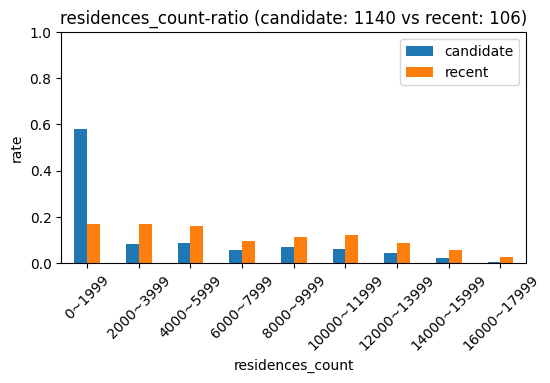

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bins = np.arange(0, 18001, 2000)
labels = [f"{bins[i]}~{bins[i+1]-1}" for i in range(len(bins)-1)]

candidate_cut = pd.cut(candidate_gdf['residences_count'], bins=bins, labels=labels, right=False)
recent_cut = pd.cut(recent_gdf['residences_count'], bins=bins, labels=labels, right=False)

candidate_ratio = candidate_cut.value_counts(normalize=True).sort_index()
recent_ratio = recent_cut.value_counts(normalize=True).sort_index()

df = pd.DataFrame({'candidate': candidate_ratio, 'recent': recent_ratio})

df.plot(kind='bar', figsize=(6,3))
plt.xlabel('residences_count')
plt.ylabel('rate')
plt.title('residences_count-ratio (candidate: 1140 vs recent: 106)')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

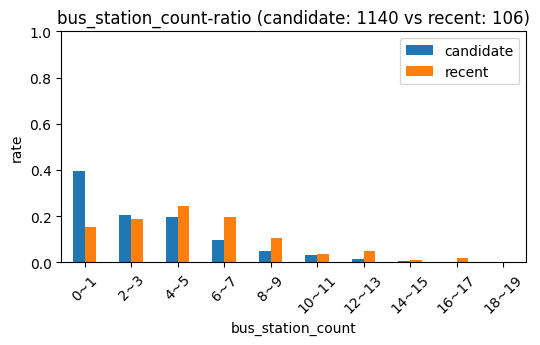

In [119]:
bins = np.arange(0, 22, 2)
labels = [f"{bins[i]}~{bins[i+1]-1}" for i in range(len(bins)-1)]

candidate_cut = pd.cut(candidate_gdf['bus_count'], bins=bins, labels=labels, right=False)
recent_cut = pd.cut(recent_gdf['bus_count'], bins=bins, labels=labels, right=False)

candidate_ratio = candidate_cut.value_counts(normalize=True).sort_index()
recent_ratio = recent_cut.value_counts(normalize=True).sort_index()

df = pd.DataFrame({'candidate': candidate_ratio, 'recent': recent_ratio})

df.plot(kind='bar', figsize=(6,3))
plt.xlabel('bus_station_count')
plt.ylabel('rate')
plt.title('bus_station_count-ratio (candidate: 1140 vs recent: 106)')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

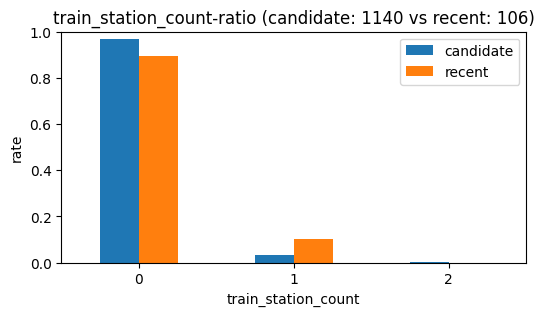

In [121]:
train_values = sorted(set(candidate_gdf['train_count']).union(set(recent_gdf['train_count'])))
candidate_ratio = candidate_gdf['train_count'].value_counts(normalize=True).reindex(train_values, fill_value=0)
recent_ratio = recent_gdf['train_count'].value_counts(normalize=True).reindex(train_values, fill_value=0)

df = pd.DataFrame({'candidate': candidate_ratio, 'recent': recent_ratio})

df.plot(kind='bar', figsize=(6,3))
plt.xlabel('train_station_count')
plt.ylabel('rate')
plt.title('train_station_count-ratio (candidate: 1140 vs recent: 106)')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

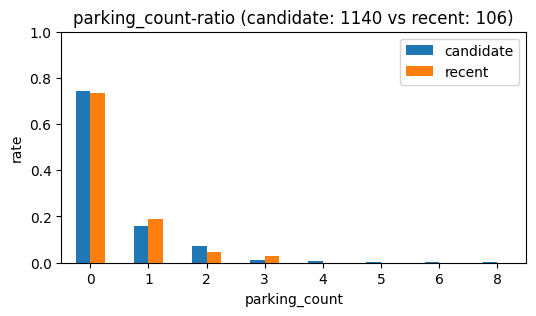

In [123]:
parking_values = sorted(set(candidate_gdf['parking_count']).union(set(recent_gdf['parking_count'])))
candidate_ratio = candidate_gdf['parking_count'].value_counts(normalize=True).reindex(parking_values, fill_value=0)
recent_ratio = recent_gdf['parking_count'].value_counts(normalize=True).reindex(parking_values, fill_value=0)

df = pd.DataFrame({'candidate': candidate_ratio, 'recent': recent_ratio})

df.plot(kind='bar', figsize=(6,3))
plt.xlabel('parking_count')
plt.ylabel('rate')
plt.title('parking_count-ratio (candidate: 1140 vs recent: 106)')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

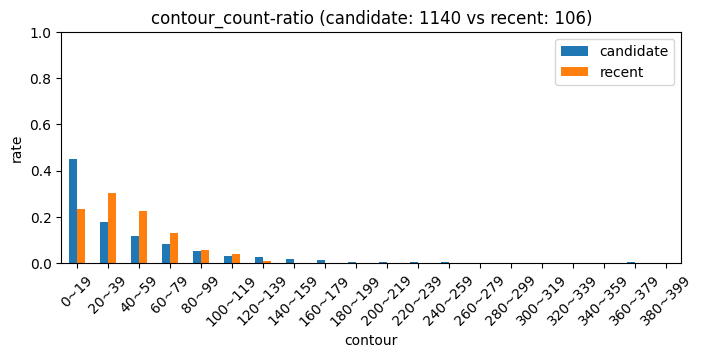

In [126]:
bins = np.arange(0, 401, 20)
labels = [f"{bins[i]}~{bins[i+1]-1}" for i in range(len(bins)-1)]

candidate_cut = pd.cut(candidate_gdf['height'], bins=bins, labels=labels, right=False)
recent_cut = pd.cut(recent_gdf['height'], bins=bins, labels=labels, right=False)

candidate_ratio = candidate_cut.value_counts(normalize=True).sort_index()
recent_ratio = recent_cut.value_counts(normalize=True).sort_index()

df = pd.DataFrame({'candidate': candidate_ratio, 'recent': recent_ratio})

df.plot(kind='bar', figsize=(8,3))
plt.xlabel('contour')
plt.ylabel('rate')
plt.title('contour_count-ratio (candidate: 1140 vs recent: 106)')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()